# Review Reply Workflow: Structured Output + Conditional Routing

This notebook builds a LangGraph workflow that automates customer review triage and response generation. It combines two techniques that are central to building reliable, production-grade LLM applications:

1. **LLM structured output** — instead of asking the model to produce free-form text and then parsing it with regex or string matching, the model is bound to a Pydantic schema via `with_structured_output`. This guarantees the output conforms to a known type (here, a `Literal` sentiment value, and separately a structured diagnosis of issue type, tone, and urgency), which downstream code can consume safely without brittle parsing.

2. **Conditional routing** — the graph does not follow a single fixed path. After the sentiment of a review is classified, a router function inspects the state and decides which node runs next: a short, appreciative reply for positive reviews, or a diagnostic-then-resolution path for negative reviews. This is implemented with `add_conditional_edges`, where the router's return value is mapped to the name of the next node.

Together these two ideas mirror a very common real-world pattern: **customer support automation**. A support pipeline typically needs to (a) understand what a customer is saying in a structured, machine-readable way, and (b) branch its behavior based on that understanding — escalating urgent bugs differently from routine positive feedback, routing angry customers differently from calm ones, and generating replies whose tone and content depend on the diagnosis. This workflow is a minimal, self-contained version of that pattern: one shared state object flows through classification, branching, and reply generation, with the LLM used twice in different roles (classifier and writer).

## Setup: Imports

This cell brings in every dependency the workflow needs:

- `StateGraph`, `START`, `END` from `langgraph.graph` build the graph structure and mark its entry/exit points.
- `ChatOpenAI` from `langchain_openai` is the chat model used both for structured classification and for free-text reply generation.
- `TypedDict` and `Literal` from `typing` define the graph's state schema and constrain fields (such as `sentiment`) to a fixed set of string values.
- `load_dotenv` from `dotenv` loads environment variables (the OpenAI API key) from a `.env` file.
- `BaseModel` and `Field` from `pydantic` define the structured-output schemas that force the LLM to return validated, typed objects instead of free-form text.

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

## Loading Environment Variables

`load_dotenv()` reads the `.env` file in the project directory and injects its contents (the OpenAI API key) into the process environment, so `ChatOpenAI` can authenticate without the key being hardcoded in the notebook. The `True` output confirms a `.env` file was found and loaded.

In [2]:
load_dotenv()

True

## Instantiating the Chat Model

A single `ChatOpenAI` instance using `gpt-4o-mini` is created. This one `model` object is reused throughout the notebook for three distinct purposes: raw sentiment classification, negative-review diagnosis, and free-text reply generation. The difference in behavior between these uses comes entirely from whether `with_structured_output` is applied and what prompt is passed in, not from creating separate model instances.

In [3]:
model = ChatOpenAI(model='gpt-4o-mini')

## Structured Schema for Sentiment Classification

`SentimentSchema` is a Pydantic `BaseModel` with a single field, `sentiment`, typed as `Literal["positive", "negative"]` and documented with a `Field(description=...)`. The description is not decorative — it is passed to the LLM as part of the schema so the model knows what the field represents when generating structured output. Constraining the type to a `Literal` of exactly two values means the model's output can only ever be one of those two strings, eliminating ambiguity that free-text sentiment analysis (e.g. "somewhat positive") would introduce.

In [4]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')

## Structured Schema for Negative-Review Diagnosis

`DiagnosisSchema` defines a richer structured output used only for negative reviews, with three `Literal`-typed fields, each with its own `Field(description=...)`:

- `issue_type`: one of `"UX"`, `"Performance"`, `"Bug"`, `"Support"`, `"Other"` — the category of problem the review describes.
- `tone`: one of `"angry"`, `"frustrated"`, `"disappointed"`, `"calm"` — the emotional register of the reviewer.
- `urgency`: one of `"low"`, `"medium"`, `"high"` — how critical the issue appears to be.

This is a second, independent structured-output contract from `SentimentSchema`. It is only invoked after a review has already been classified as negative, and its fields are exactly what the negative-response node later reads to tailor its reply.

In [5]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')


## Binding the Schemas to the Model

`model.with_structured_output(SentimentSchema)` and `model.with_structured_output(DiagnosisSchema)` each wrap the base `model` so that invoking them returns a validated instance of the corresponding Pydantic class rather than a plain chat message. `structured_model` is used for sentiment classification; `structured_model2` is used for diagnosing negative reviews. Because `with_structured_output` returns a new runnable rather than mutating `model` in place, the original `model` remains available for ordinary free-text generation (used later in `positive_response` and `negative_response`).

In [6]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

## Ad Hoc Test of Structured Sentiment Output

Before wiring `structured_model` into the graph, it is exercised directly with a standalone prompt: `"What is the sentiment of the following review - The software too good"`. Calling `.invoke(prompt)` returns a `SentimentSchema` instance, and `.sentiment` accesses its typed field directly — no string parsing is needed. The output, `'positive'`, confirms the schema binding works as expected before it is used inside a graph node.

In [7]:
prompt = 'What is the sentiment of the following review - The software too good'
structured_model.invoke(prompt).sentiment

'positive'

## Graph State Schema

`ReviewState` is a `TypedDict` with four fields that together form the single shared state object threaded through every node in the graph:

- `review: str` — the original customer review text, set once at invocation and read by every downstream node.
- `sentiment: Literal["positive", "negative"]` — written by `find_sentiment`, read by the router (`check_sentiment`).
- `diagnosis: dict` — written by `run_diagnosis` (only reached on the negative branch), read by `negative_response`.
- `response: str` — the final generated reply, written by either `positive_response` or `negative_response`, and present in the graph's output regardless of which branch executed.

Not every field is populated on every run: a positive review never populates `diagnosis`, since that branch never executes `run_diagnosis`.

In [8]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

## Node Functions and the Router

This cell defines every node function and the routing logic used by the graph:

- **`find_sentiment(state)`** builds a prompt embedding `state["review"]` and calls `structured_model.invoke(...)`, extracting `.sentiment`. It returns a partial state update `{'sentiment': sentiment}`, which LangGraph merges into the overall state.

- **`check_sentiment(state)`** is the router function, type-hinted to return `Literal["positive_response", "run_diagnosis"]`. It reads `state['sentiment']` and returns the string `'positive_response'` if positive, otherwise `'run_diagnosis'`. These returned strings are not arbitrary — they are exactly the node names that `add_conditional_edges` will map to in the next cell.

- **`positive_response(state)`** builds a prompt asking the model to write a warm thank-you message referencing `state['review']` and to invite the user to leave feedback on the website. It calls `model.invoke(...).content` (plain, unstructured generation) and returns `{'response': response}`.

- **`run_diagnosis(state)`** builds a prompt asking the model to diagnose the negative review, and calls `structured_model2.invoke(...)`, which returns a `DiagnosisSchema` instance. `.model_dump()` converts it to a plain dict, returned as `{'diagnosis': response.model_dump()}` so it can be stored in the `diagnosis: dict` state field.

- **`negative_response(state)`** reads `state['diagnosis']` and interpolates its `issue_type`, `tone`, and `urgency` fields into a prompt instructing the model to act as a support assistant and write an empathetic resolution message. It calls `model.invoke(...).content` and returns `{'response': response}`.

Together these five functions implement the full classify-then-branch-then-reply logic; the graph wiring in the next cell only decides the order and conditions under which they run.

In [9]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}
    

## Building and Compiling the Graph

`graph = StateGraph(ReviewState)` creates a new graph typed to the `ReviewState` schema. Four nodes are registered with `add_node`, each mapping a string name to one of the previously defined functions: `find_sentiment`, `positive_response`, `run_diagnosis`, `negative_response`.

The edges establish control flow:

- `graph.add_edge(START, 'find_sentiment')` makes sentiment classification the entry point of every run.
- `graph.add_conditional_edges('find_sentiment', check_sentiment)` is the branching step: after `find_sentiment` runs, `check_sentiment` is called with the current state, and its return value (`'positive_response'` or `'run_diagnosis'`) determines which node executes next. Because these return values match registered node names exactly, no explicit mapping dictionary is needed here.
- `graph.add_edge('positive_response', END)` ends the positive branch immediately after the thank-you reply is generated.
- `graph.add_edge('run_diagnosis', 'negative_response')` chains diagnosis into resolution-message generation on the negative branch.
- `graph.add_edge('negative_response', END)` ends the negative branch after the resolution reply is generated.

`graph.compile()` validates this structure and produces `workflow`, an executable graph that can be invoked with an initial state.

In [10]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)
graph.add_edge('positive_response', END)
graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

## Visualizing the Compiled Graph

Displaying `workflow` on its own renders LangGraph's built-in graph visualization, showing `find_sentiment` as the single entry point branching into either `positive_response` or the `run_diagnosis` → `negative_response` chain, with both branches converging on `END`. This is a visual check that the wiring from the previous cell matches the intended structure — one classification node, a two-way conditional split, and two independent paths to termination.

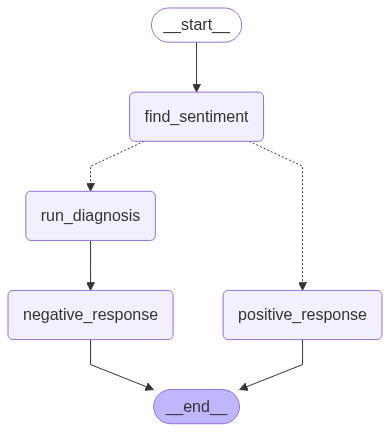

In [11]:
workflow

## Running the Workflow on a Negative Review

`intial_state` supplies only `review`, describing a login bug where the app freezes on the authentication screen. `workflow.invoke(intial_state)` runs the full graph starting from this partial state.

Reading the output:

- `sentiment` is `'negative'`, so `find_sentiment` routed execution to `run_diagnosis` rather than `positive_response`.
- `diagnosis` shows `{'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'}` — the structured classification produced by `structured_model2` and reduced to a dict via `.model_dump()`.
- `response` is the empathetic resolution message from `negative_response`, generated by interpolating those exact `issue_type`, `tone`, and `urgency` values into its prompt — visible in phrases like "I completely understand how frustrating it can be" (matching `tone: 'frustrated'`) and the request for more diagnostic detail (matching `issue_type: 'Bug'`).

The `review` field is also echoed back unchanged, since LangGraph merges each node's partial return dict into the running state rather than replacing it, so fields no node touches (here, none, but in general) persist unchanged and fields multiple nodes write can be inspected in the final merged output.

In [12]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': "Subject: We're Here to Help with Your Bug Issue\n\nHi [User's Name],\n\nI hope this message finds you well. I completely understand how frustrating it can be to experience a bug, especially when it’s impacting your work. Your concern is important to us, and I want to assure you that we are here to help.\n\nTo assist you better, could you please provide more details about the issue you're facing? Specifically, any error messages you’ve encountered, the steps that led up to the bug, or any screenshots you can share would be incredibly helpful. \n\nWe want to resolve this as quickly as possible for you, so your prompt response will 

## Summary

This notebook demonstrates the combination of **structured LLM output** and **conditional graph routing** in LangGraph:

- Two Pydantic schemas (`SentimentSchema`, `DiagnosisSchema`) constrain the model's output to typed, validated fields via `with_structured_output`, removing the need for manual text parsing anywhere in the pipeline.
- A router function (`check_sentiment`) inspects classified state and returns the name of the next node to run, wired into the graph with `add_conditional_edges`, so the same graph produces two structurally different execution paths depending on input.
- The positive path is a single short node; the negative path is a two-step chain (diagnosis, then a diagnosis-informed reply), showing that branches in a conditional graph need not be symmetric in length or complexity.
- A single `ReviewState` `TypedDict` carries all data — raw review, classification, diagnosis, and final response — across nodes, with each node contributing a partial update that LangGraph merges into the whole.

This pattern generalizes directly to customer support automation, content moderation triage, ticket routing, and any workflow where an LLM must first classify input into a structured category and then take materially different actions depending on that category — replacing hand-written if/else logic over unstructured text with a typed classification step feeding a declarative graph.